# Design and implementation of the codec

In [1]:
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import soundfile as sf
from matplotlib import pyplot as plt
from numpy.fft import rfft
from scipy.linalg import solve_toeplitz
from scipy.signal import get_window, lfilter

# Selection of the parameter values

In [2]:
LPC_ORDER = 10
ACORR_WIN = "hamming"  # tukey is better but ok
FRAME_LENGTH = 0.025
FFT_N = 1024

In [3]:
DATA_MALE_PATH = Path("Male_sentences_8kHz")
DATA_FEMALE_PATH = Path("Female_sentences_8kHz")
EXAMPLE_MALE_PATH = DATA_MALE_PATH / "si745_8kHz.wav"
EXAMPLE_FEMALE_PATH = DATA_FEMALE_PATH / "si747_8kHz.wav"

# LP analysis and synthesis without quantization

Small change from the original suggestion - store the warm-up samples inside the residual as this makes the whole process easier and doesn't involve the use of zi or other operations including Z-transforms that might affect accuracy

In [4]:
def autocorr(signal: np.array, target_len: int) -> np.array:
    """
    Computes autocorrelation
    :param signal: signal to be autocorrelated
    :param target_len: number of coefficients
    :return: autocorrelation coefficients
    """
    return np.asarray([signal[:len(signal) - i].dot(signal[i:]) for i in range(target_len)])


def calculate_lpc_coefficients(signal: np.ndarray, order: int) -> np.ndarray:
    """
    Calculates LPC coefficents
    :param signal: input signal to calculate LPC coefficients from
    :param order: LPC order
    :return: LPC coefficients as filter parameters suitable for lfilter 
    """
    window = get_window(ACORR_WIN, len(signal))
    r = autocorr(signal * window, order + 1)

    lpc_raw = solve_toeplitz(r[:-1], r[1:], check_finite=False)

    # add a x1 coefficient for the current sample and invert the LPC so we subtract the predicted sum
    # using LPC with these coefficients will result in the residual without any necessary subtraction step
    # this also allows for inverse filtering even without setting initial values for the delay line
    # (since the warm-up samples are still in the residual - see beginning of example frame residual)
    return np.pad(-lpc_raw, (1, 0), constant_values=1)


def compute_residual(signal: np.ndarray, lpc_c: np.ndarray) -> np.ndarray:
    return lfilter(lpc_c, [1], signal)


def restore_signal(signal: np.ndarray, lpc_c: np.ndarray) -> np.ndarray:
    return lfilter([1], lpc_c, signal)

In [5]:
def lpc_analysis(frame: np.ndarray) -> (np.ndarray, np.ndarray):
    lpc_c = calculate_lpc_coefficients(frame, LPC_ORDER)
    residual = compute_residual(frame, lpc_c)
    return residual, lpc_c


def lpc_synthesis(frame_residual: np.ndarray, lpc_c: np.ndarray) -> np.ndarray:
    return restore_signal(frame_residual, lpc_c)


def process_frame(frame: np.ndarray) -> Dict[str, np.ndarray]:
    resid, lpc_c = lpc_analysis(frame)
    restored = lpc_synthesis(resid, lpc_c)
    return {"Frame": frame, "LPC Coefficients": lpc_c, "Residual": resid, "Synthetized Frame": restored}

In [6]:
def lpc(file_path: Path):
    with sf.SoundFile(file_path, "r") as f:
        sr = f.samplerate
        frames = list(f.blocks(blocksize=int(sr * FRAME_LENGTH), dtype="float64"))

    if len(frames[0].shape) != 1:
        raise RuntimeError("This codec only supports mono audio")

    return pd.DataFrame.from_records([process_frame(f) for f in frames])


df_lpc_male = lpc(EXAMPLE_MALE_PATH)
df_lpc_female = lpc(EXAMPLE_FEMALE_PATH)

### Plot one nice speech frame for comparison

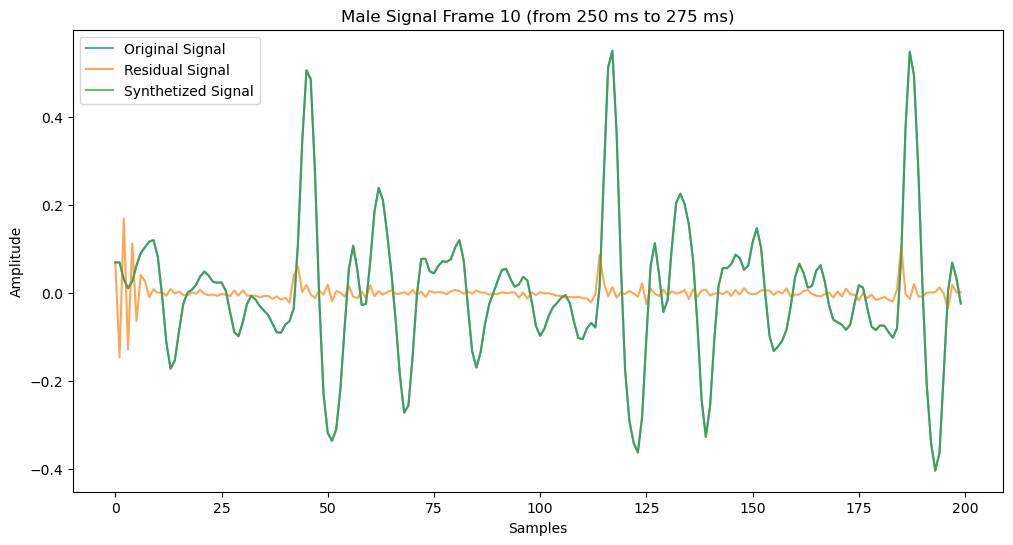

In [7]:
example_frame_idx = 10

plt.figure(figsize=(12, 6))
plt.plot(df_lpc_male.loc[example_frame_idx, "Frame"], label="Original Signal", alpha=0.7)
plt.plot(df_lpc_male.loc[example_frame_idx, "Residual"], label="Residual Signal", alpha=0.7)
plt.plot(df_lpc_male.loc[example_frame_idx, "Synthetized Frame"], label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title(f"Male Signal Frame {example_frame_idx} (from "
          f"{example_frame_idx * FRAME_LENGTH * 1000:.0f} ms to "
          f"{(example_frame_idx + 1) * FRAME_LENGTH * 1000:.0f} ms)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Plot whole signal as the assignment requires

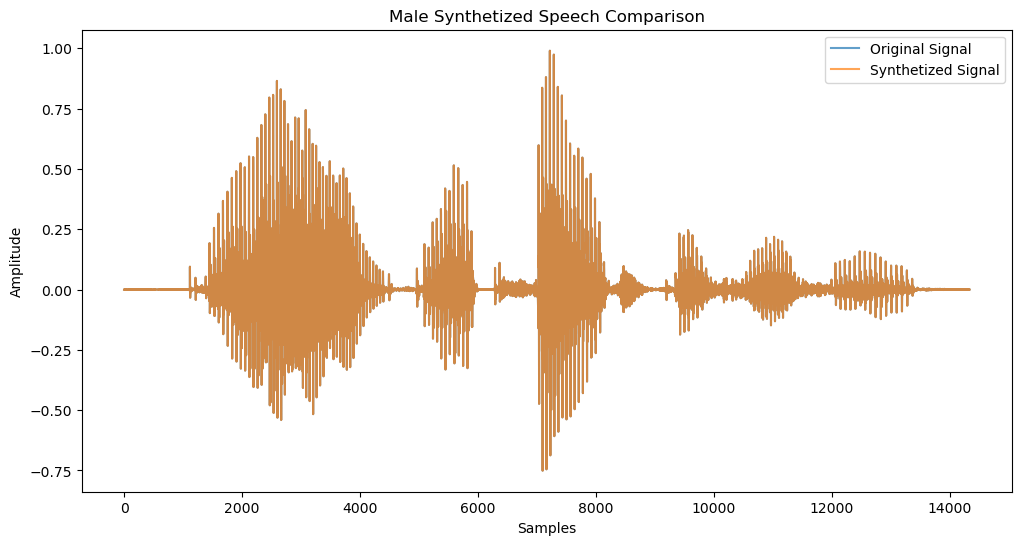

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(np.concatenate(df_lpc_male["Frame"]), label="Original Signal", alpha=0.7)
plt.plot(np.concatenate(df_lpc_male["Synthetized Frame"]), label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title("Male Synthetized Speech Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Differences
Just to illustrate the similarity better, let's plot the max difference between the original and the synthetized signal in each frame 

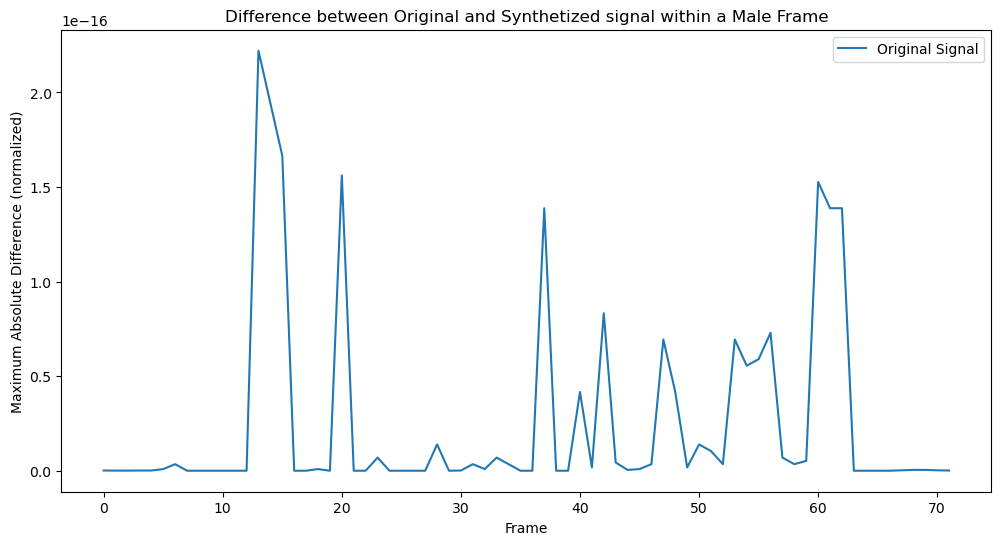

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df_lpc_male.apply(lambda x: abs(x["Frame"] - x["Synthetized Frame"]).max(), axis=1), label="Original Signal")
plt.legend()
plt.title("Difference between Original and Synthetized signal within a Male Frame")
plt.xlabel("Frame")
plt.ylabel("Maximum Absolute Difference (normalized)")
plt.show()

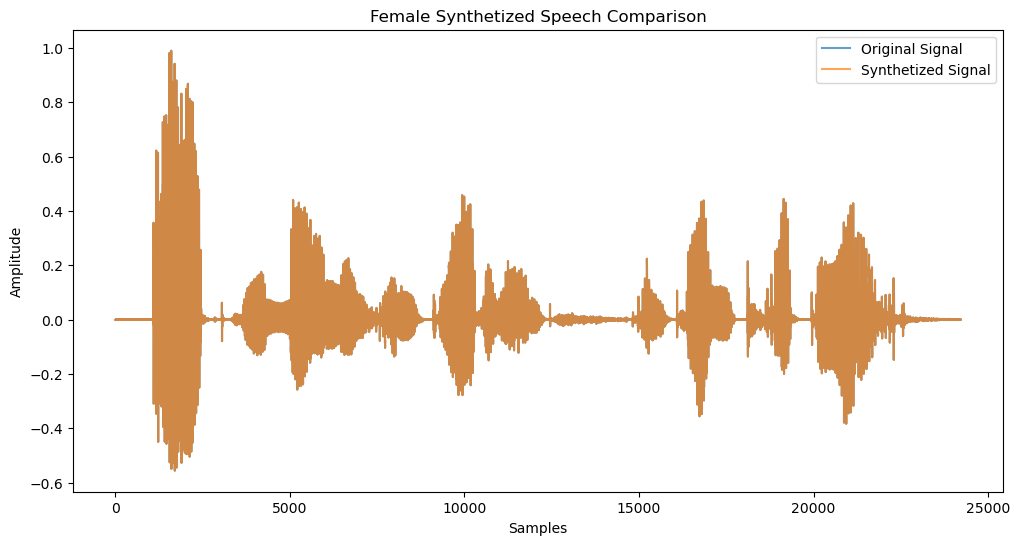

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(np.concatenate(df_lpc_female["Frame"]), label="Original Signal", alpha=0.7)
plt.plot(np.concatenate(df_lpc_female["Synthetized Frame"]), label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title("Female Synthetized Speech Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

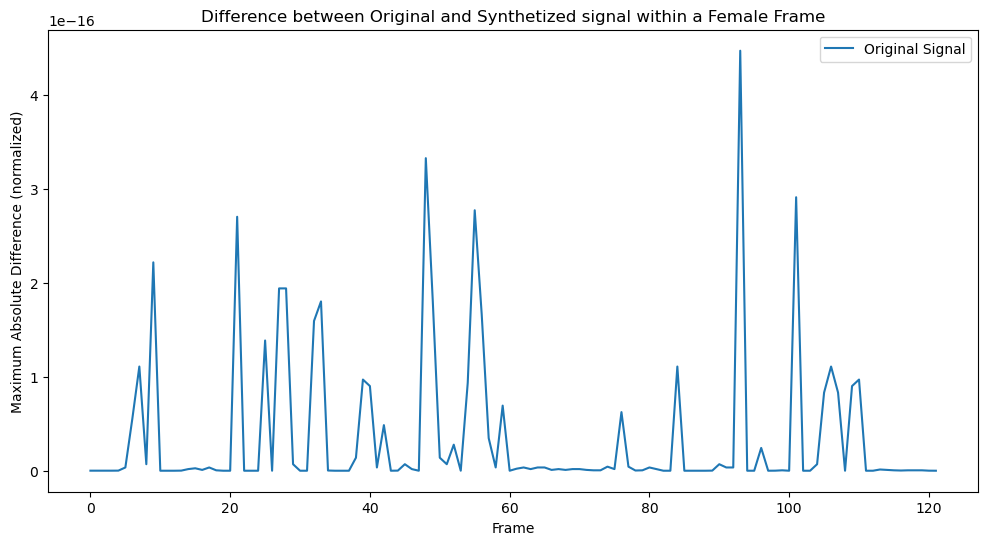

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df_lpc_female.apply(lambda x: abs(x["Frame"] - x["Synthetized Frame"]).max(), axis=1), label="Original Signal")
plt.legend()
plt.title("Difference between Original and Synthetized signal within a Female Frame")
plt.xlabel("Frame")
plt.ylabel("Maximum Absolute Difference (normalized)")
plt.show()

# Quantization of the LP filter

In [12]:
def sdsq(lpc_c: np.ndarray, qlp_c: np.ndarray) -> np.float64:
    po = abs(rfft(lpc_c, n=FFT_N))**2 
    pq = abs(rfft(qlp_c, n=FFT_N))**2
    return np.mean((10*np.log10(po) - 10*np.log10(pq))**2)

def sd(lpc_c: np.ndarray, qlp_c: np.ndarray) -> np.float64:
    return np.sqrt(sdsq(lpc_c, qlp_c))

In [13]:
def lpc_to_lattice(h: np.ndarray) -> np.ndarray:
    h = np.array(h, dtype=float)  # make a copy
    N = len(h)
    a = h.copy()
    k = np.zeros(N)

    for m in range(N-1, 0, -1):
        k[m] = a[m]
        if np.abs(1 - k[m]**2) < 1e-10:
            raise ValueError("Unstable filter detected (reflection coefficient near ±1).")
        a_new = np.zeros(m)
        for i in range(m):
            a_new[i] = (a[i] - k[m] * a[m-1-i]) / (1 - k[m]**2)
        a[:m] = a_new  # update only first m coefficients

    k[0] = a[0]
    return k

def lattice_to_lpc(k: np.ndarray) -> np.ndarray:
    k = np.array(k, dtype=float)
    N = len(k)
    a = np.zeros(N)
    a[0] = k[0]

    for m in range(1, N):
        a_new = np.zeros(m+1)
        for i in range(m):
            a_new[i] = a[i] + k[m] * a[m-1-i]
        a_new[m] = k[m]
        a[:m+1] = a_new

    return a

In [14]:
def quantize_lattice(lattice_coeffs, num_bits): 
    """Quantize lattice coefficients using uniform scalar quantization."""
    # TODO: ensure LPC filter is stable
    step_size = 2 / (2**num_bits)  # Define step size for uniform quantization
    quantized_lattice = np.round(lattice_coeffs / step_size) * step_size
    return quantized_lattice

In [15]:
def quantized_lpc_distortion(lpc_c: np.ndarray, n_bits: int) -> np.float64:
    lattice_c = lpc_to_lattice(lpc_c)
    quantized_lattice = quantize_lattice(lattice_c, n_bits)
    qlp_c = lattice_to_lpc(quantized_lattice)
    return sd(lpc_c, qlp_c)

def calculate_spectral_distortions(row: pd.Series, num_bits_list=(5, 4, 3)):
    for bits in num_bits_list:
        row[f"SD for {bits} bits"] = quantized_lpc_distortion(row["LPC Coefficients"], bits)
    return row

df_lpc_male_distortions = df_lpc_male.apply(calculate_spectral_distortions, axis=1)
df_lpc_female_distortions = df_lpc_female.apply(calculate_spectral_distortions, axis=1)

In [16]:
def print_sd_avg(df: pd.DataFrame, num_bits_list=(5, 4, 3)):
    for bits in num_bits_list:
        colname = f"SD for {bits} bits"
        print(f"Average SD for {bits} bits: {df[colname].mean():.3f}")

print(f"Average distortions:")
print(f"=== File: {EXAMPLE_MALE_PATH} ===")
print_sd_avg(df_lpc_male_distortions)
print(f"=== File: {EXAMPLE_FEMALE_PATH} ===")
print_sd_avg(df_lpc_female_distortions)

Average distortions:
=== File: Male_sentences_8kHz/si745_8kHz.wav ===
Average SD for 5 bits: 3.699
Average SD for 4 bits: 5.164
Average SD for 3 bits: 7.607
=== File: Female_sentences_8kHz/si747_8kHz.wav ===
Average SD for 5 bits: 3.530
Average SD for 4 bits: 5.263
Average SD for 3 bits: 7.497
